The total price an investor asking for a required return of 12% would pay is $5,975,984.55.
Paying 50.31 cents on the dollar.
Different Return Portfolio Price   vs Base
             10%      $6,137,249  $181,930
             11%      $6,038,977   $83,658
             12%      $5,955,319        $0
             13%      $5,877,672  $-77,646
             14%      $5,820,328 $-134,991
             15%      $5,743,500 $-211,819


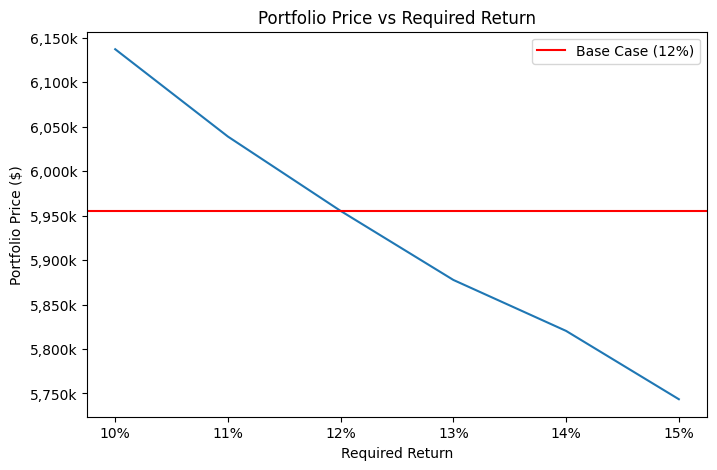

Different foreclosure time Portfolio Price   vs Base
                     0.75x      $6,201,110  $224,346
                     1.00x      $5,976,764        $0
                     1.25x      $5,745,937 $-230,827
                     1.50x      $5,559,714 $-417,050
                     1.75x      $5,315,083 $-661,681
                     2.00x      $5,133,352 $-843,412


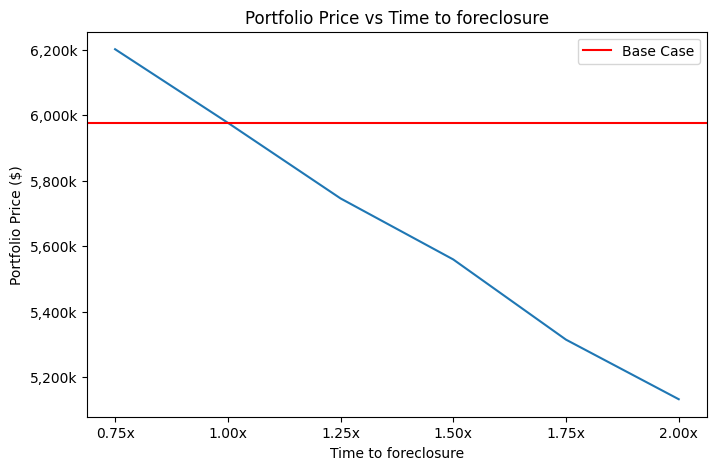

Price Shock Portfolio Price     vs Base
       -40%      $3,590,896 $-2,387,338
       -30%      $4,168,170 $-1,810,064
       -20%      $4,779,114 $-1,199,120
       -10%      $5,371,633   $-606,601
         0%      $5,978,234          $0
        10%      $6,582,051    $603,817
        20%      $7,182,871  $1,204,637


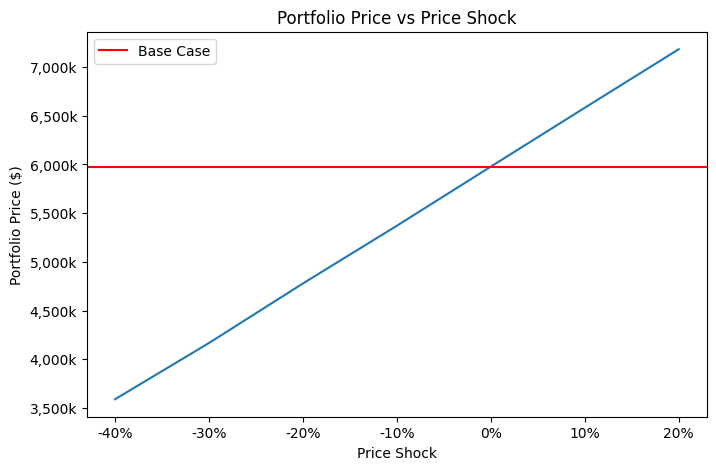

Comparison between simple Monte Carlo and with systemic shock:
Base mean: $5,971,551
Correlated mean: $5,971,200
Base std: $370,389
Correlated std: $696,481
Base 5th percentile: $5,423,059
Correlated 5th percentile: $4,850,489


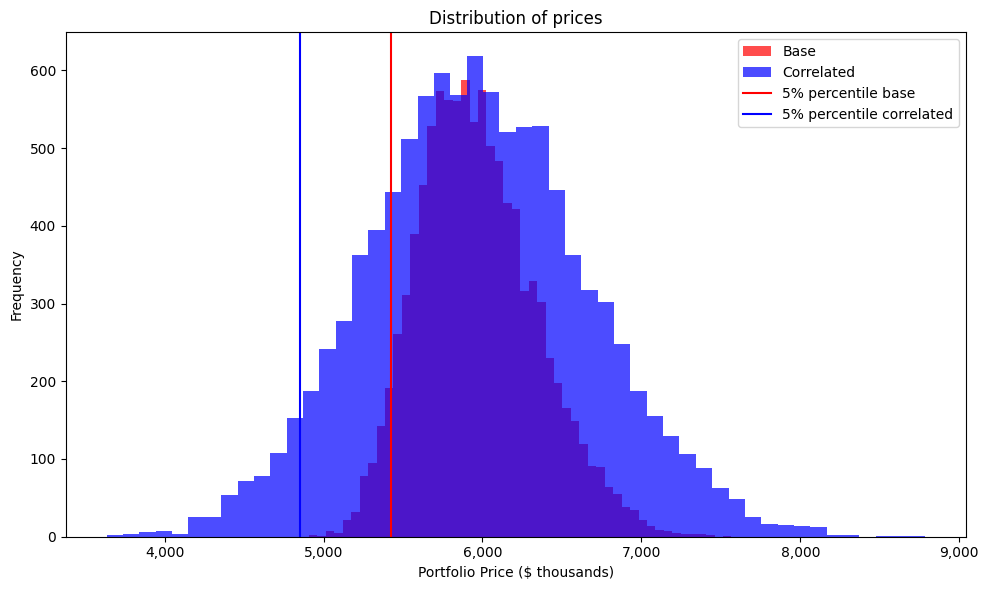

In [15]:
# NPL Portfolio Pricer:
# Model for pricing a portfolio of non-performing mortgage loans using a Monte Carlo simulation framework.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = 0.12 # Required return for NPL investor

# Probabilities:
p_loss_mitigation = 0.1 # Probability loss mitigation resolves
p_sell_auction = 0.2 # Probability sell at auction
p_occupied = 0.45 # Probability probability is occupied and eviction needs to happen

# Legal path:
judicial_states = [
    "FL", "NY", "NJ", "IL", "OH", "IN", "KS", "KY", "LA", "ME",
    "MD", "MA", "NE", "NM", "ND", "PA", "SC", "VT", "WI", "WY",
    "DE", "HI", "IA", "MN", "MO", "MT", "NH", "OK", "SD", "CT",
    "AR", "GA", "MI"
]

# Time to foreclosure
t_foreclosure_parameters = {
    "non_judicial": {"mean": 6,  "std": 2},
    "judicial":     {"mean": 18, "std": 8}
}

# Haircuts:
h_REO = 0.35
h_auction = 0.25

# Time to sale:
t_sale_REO = 6
t_eviction = 4

# Other costs:
cost_eviction = 3000

# Loss mitigation probabilities:
p_loss_mitigation_options = {
    "repayment_full": 0.02,
    "repayment_partial": 0.1,
    "loan_modification": 0.25,
    "short_sale": 0.28,
    "DIL": 0.35
  }

# Timeline to debt recovery
t_mitigation = {
    "repayment_full": 2,
    "repayment_partial": 4,
    "loan_modification": 12,
    "short_sale": 5,
    "DIL": 2 + t_sale_REO
  }

# Single loan pricing: models five loss mitigation outcomes, judicial vs non-judicial, foreclosure tracks, auction, and REO scenarios

def price_single_loan(D, P, state):

  track = "judicial" if state in judicial_states else "non_judicial"

  # Include all parameters that use D or P, as they're different in each loan
  cost_legal = {  # Legal costs.
      "non_judicial" : 0.02 * D,
      "judicial": 0.05 * D}

  loss_mitigation_recovery = {
      "repayment_full": 1 * D, # Percentage of debt recovery
      "repayment_partial": 0.85 * D,
      "loan_modification": 0.92 * D,
      "short_sale": 0.85 * P,
      "DIL": P # placeholder as calculation is different for DIL, it becomes REO
  }
  cost_carry = 0.03 * P # annual

  if np.random.random() < p_loss_mitigation: # Loss mitigation
    outcomes = ["repayment_full", "repayment_partial", "loan_modification", "short_sale", "DIL"]
    outcome = np.random.choice(outcomes, p=list(p_loss_mitigation_options.values()))
    recovery = loss_mitigation_recovery[outcome]
    t = t_mitigation[outcome]
    if outcome == "DIL":
      V = (P * (1 - h_REO) - cost_carry * (t/12)) / ((1 + d) ** (t / 12))
    else:
      V = recovery / (1 + d) ** (t/12)
  else: # Property has to go through foreclosure process
    t_auction = max(1, np.random.normal(loc=t_foreclosure_parameters[track]["mean"], scale=t_foreclosure_parameters[track]["std"])) # max prevents negative times
    if np.random.random() < p_sell_auction: # will sell at auction
      V = (P * (1 - h_auction) - cost_legal[track]) / (1 + d) ** (t_auction/12)
    else: # property becomes REO
      if np.random.random() < p_occupied: # will be occupied, need to evict
        V = (P * (1 - h_REO) - cost_legal[track] - cost_carry * ((t_auction + t_sale_REO + t_eviction) / 12) - cost_eviction) / (1 + d) ** ((t_auction + t_sale_REO + t_eviction)/12)
      else: # vacant REO
        V = (P * (1 - h_REO) - cost_legal[track] - cost_carry * ((t_auction + t_sale_REO) / 12)) / (1 + d) ** ((t_auction + t_sale_REO)/12)
  return V

portfolio = pd.DataFrame({
    "loan_id": [f"L{i:03d}" for i in range(1, 21)],
    "state": ["FL", "NY", "CA", "TX", "NJ", "IL", "AZ", "OH", "GA", "NC",
              "FL", "NJ", "CA", "NY", "TX", "FL", "OR", "CT", "VA", "MI"],
    "appraised_value": [200000, 1000000, 500000, 350000, 180000, 2000000,
                        275000, 425000, 315000, 480000, 550000, 750000,
                        890000, 1200000, 310000, 420000, 385000, 675000,
                        290000, 515000],
    "UPB": [190000, 900000, 480000, 400000, 190000, 1850000,
            260000, 410000, 320000, 500000, 520000, 720000,
            850000, 1150000, 295000, 430000, 370000, 650000,
            310000, 490000],
    "accrued_interest": [10000, 20000, 30000, 82000, 10000, 40000,
                         15000, 25000, 18000, 35000, 22000, 45000,
                         38000, 55000, 12000, 28000, 20000, 42000,
                         16000, 30000]
})
portfolio["D"] = portfolio["UPB"] + portfolio["accrued_interest"]
portfolio["P"] = portfolio["appraised_value"]

# Monte Carlo
def run_montecarlo(portfolio, simulations=10000):
  prices = []
  for i in range(simulations):
    price = portfolio.apply(
      lambda row: price_single_loan(row["D"], row["P"], row["state"]),
      axis=1).sum() # row by row
    prices.append(price)
  return prices

base_price = np.mean(run_montecarlo(portfolio))
print(f"The total price an investor asking for a required return of 12% would pay is ${base_price:,.2f}.")
print(f"Paying {base_price/portfolio['D'].sum()*100:.0f} cents on the dollar.")


# Stress testing
# Increase in required return
different_returns = [0.1, 0.11, 0.12, 0.13, 0.14, 0.15]
results_returns = []
for different_return in different_returns:
  d = different_return
  result = np.mean(run_montecarlo(portfolio, 1000))
  results_returns.append(result)

return_sensitivity = pd.DataFrame({
    "Different Return" : [f"{different_return:.0%}" for different_return in different_returns],
    "Portfolio Price": [f"${result:,.0f}" for result in results_returns],
    "vs Base": [f"${result - results_returns[2]:,.0f}" for result in results_returns]
})
print(return_sensitivity.to_string(index=False))

plt.figure(figsize=(8,5))
plt.plot(different_returns, results_returns)
plt.xlabel("Required Return")
plt.ylabel("Portfolio Price ($)")
plt.title("Portfolio Price vs Required Return")
plt.axhline(y=results_returns[2], color="red", label="Base Case (12%)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p:f"{x/1000:,.0f}k"))

plt.legend()
plt.show()

# Change in foreclosure timeline
d = 0.12 # reset required return
multipliers = [0.75, 1, 1.25, 1.5, 1.75, 2]
results_times = []

for multiplier in multipliers:
  t_foreclosure_parameters = {
    "non_judicial": {"mean": 6 * multiplier,  "std": 2},
    "judicial":     {"mean": 18 * multiplier, "std": 8}
  }
  result = np.mean(run_montecarlo(portfolio, 1000))
  results_times.append(result)

foreclosure_time_sensitivity = pd.DataFrame({
    "Different foreclosure time": [f"{multiplier:.2f}x" for multiplier in multipliers],
    "Portfolio Price": [f"${result:,.0f}" for result in results_times],
    "vs Base": [f"${result - results_times[1]:,.0f}" for result in results_times]
})
print(foreclosure_time_sensitivity.to_string(index=False))

t_foreclosure_parameters = { #reset
    "non_judicial": {"mean": 6,  "std": 2},
    "judicial":     {"mean": 18, "std": 8}
}
plt.figure(figsize=(8,5))
plt.plot(multipliers, results_times)
plt.xlabel("Time to foreclosure")
plt.ylabel("Portfolio Price ($)")
plt.title("Portfolio Price vs Time to foreclosure")
plt.axhline(y=results_times[1], color="red", label="Base Case")
plt.xticks(multipliers)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p:f"{x:.2f}x"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p:f"{x/1000:,.0f}k"))
plt.legend()
plt.show()

# Sensitivity table for shock in prices
shocks = [-0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2]
results_shocks = []
for shock in shocks:
  stressed_portfolio = portfolio.copy()
  stressed_portfolio["P"] = stressed_portfolio["P"] * (1 + shock)
  result = np.mean(run_montecarlo(stressed_portfolio, 1000))
  results_shocks.append(result)

market_prices_sensitivity = pd.DataFrame({
    "Price Shock" : [f"{shock:.0%}" for shock in shocks],
    "Portfolio Price": [f"${result:,.0f}" for result in results_shocks],
    "vs Base": [f"${result - results_shocks[4]:,.0f}" for result in results_shocks],
})
print(market_prices_sensitivity.to_string(index=False))

plt.figure(figsize=(8,5))
plt.plot(shocks, results_shocks)
plt.xlabel("Price Shock")
plt.ylabel("Portfolio Price ($)")
plt.title("Portfolio Price vs Price Shock")
plt.axhline(y=results_shocks[4], color="red", label="Base Case")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p:f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p:f"{x/1000:,.0f}k"))
plt.legend()
plt.show()


# Monte Carlo with systemic uncertain market shocks
def run_montecarlo_shock(portfolio, simulations=10000, sigma=0.1):
  prices = []
  for i in range(simulations):
    epsilon = np.random.normal(0,sigma)
    shocked_portfolio = portfolio.copy()
    shocked_portfolio["P"] = shocked_portfolio["P"] * (1 + epsilon)
    price = shocked_portfolio.apply(
      lambda row: price_single_loan(row["D"], row["P"], row["state"]),
      axis=1).sum()
    prices.append(price)
  return prices

base_prices = run_montecarlo(portfolio)
shock_prices = run_montecarlo_shock(portfolio)

print(f"Comparison between simple Monte Carlo and with systemic shock:")
print(f"Base mean: ${np.mean(base_prices):,.0f}")
print(f"Correlated mean: ${np.mean(shock_prices):,.0f}")
print(f"Base std: ${np.std(base_prices):,.0f}")
print(f"Correlated std: ${np.std(shock_prices):,.0f}")
print(f"Base 5th percentile: ${np.percentile(base_prices, 5):,.0f}")
print(f"Correlated 5th percentile: ${np.percentile(shock_prices, 5):,.0f}") # we can confirm that using correlation changes the tail risk, not the expected value

plt.figure(figsize=(10,6))
plt.hist(base_prices, bins=50, color='red', alpha=0.7, label='Base')
plt.hist(shock_prices, bins=50, color='blue', alpha=0.7, label='Correlated')
plt.axvline(x=np.percentile(base_prices, 5), color='red', label='5% percentile base')
plt.axvline(x=np.percentile(shock_prices, 5), color='blue', label='5% percentile correlated')
plt.title('Distribution of prices')
plt.xlabel('Portfolio Price ($ thousands)')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p:f"{x/1000:,.0f}"))
plt.legend()
plt.tight_layout()
plt.show()